# 05 - YOLOX inference demo (MyYoloX)

Este notebook sigue el estilo de los notebooks de exploracion del proyecto, pero orientado a una prueba completa de inferencia con YOLOX: carga DICOM, preprocesado y deteccion de bounding boxes.

Requisito: ejecutar el kernel en el entorno del contenedor donde MyYoloX este instalado (`pip install -e /workspace/MyYoloX`).

In [1]:
import sys
import random
from pathlib import Path

import pydicom
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from utils.utils import find_dicom_images
from utils.yolox_interface import YOLOXNotebookInterface

from image.apply_windowing import apply_windowing
from image.calculate_windowing import (
                                get_dicom_voi_lut_params, 
                                normalize_photometric,
                                )

In [2]:
# Rutas dentro del contenedor.
# Datasets locales montados en /workspace/Data  (host: ~/Escritorio/Datasets)
DEFAULT_DATASET_DIR = Path('/workspace/Data/INbreast/AllDICOMs/')
# DEFAULT_DATASET_DIR = Path('/workspace/Data/Mammo-MX/B1')

YOLOX_ROOT = project_root / 'MyYoloX'
EXP_FILE   = YOLOX_ROOT / 'exps/default/yolox_nano.py'
CKPT_FILE  = YOLOX_ROOT / 'archive/yolox_nano_416_roi_torch.pth'

DEVICE = 'gpu'   # cambia a 'cpu' si no tienes CUDA disponible
TSIZE  = 416
CONF   = 0.25
NMS    = 0.45

print('project_root:', project_root)
print('dataset exists:', DEFAULT_DATASET_DIR.exists(), DEFAULT_DATASET_DIR)
print('exp exists:    ', EXP_FILE.exists(),   EXP_FILE)
print('ckpt exists:   ', CKPT_FILE.exists(),  CKPT_FILE)

project_root: /workspace
dataset exists: True /workspace/Data/INbreast/AllDICOMs
exp exists:     True /workspace/MyYoloX/exps/default/yolox_nano.py
ckpt exists:    True /workspace/MyYoloX/archive/yolox_nano_416_roi_torch.pth


In [3]:
dicom_paths = find_dicom_images(DEFAULT_DATASET_DIR, include_extensionless=True)
print(f'Total DICOM encontrados: {len(dicom_paths)}')

if not dicom_paths:
    raise RuntimeError('No se encontraron DICOMs. Revisa DEFAULT_DATASET_DIR.')

idx = random.randint(0, len(dicom_paths) - 1)
image_path = dicom_paths[idx]
print('Indice:', idx)
print('Imagen seleccionada:', image_path)

Total DICOM encontrados: 410
Indice: 265
Imagen seleccionada: /workspace/Data/INbreast/AllDICOMs/50994787_069212ec65a94339_MG_L_CC_ANON.dcm


In [4]:
metadata = pydicom.dcmread(image_path)
original_image = metadata.pixel_array
original_image, _ = normalize_photometric(original_image, metadata)

try:
    voilut = get_dicom_voi_lut_params(metadata)
    print(voilut)
    windowed_image = apply_windowing(
        original_image,
        window_width=voilut['window_width'],
        window_center=voilut['window_center'],
        voi_func=voilut['voi_lut_function'],
        y_min=float(original_image.min()),
        y_max=float(original_image.max()),
        backend='np_v2',
    )
except Exception:
    # Fallback: si no hay VOI LUT usable, usamos la imagen normalizada
    windowed_image = original_image

{'window_center': 1528, 'window_width': 807, 'rescale_intercept': 0.0, 'rescale_slope': 1.0, 'voi_lut_function': 'LINEAR'}


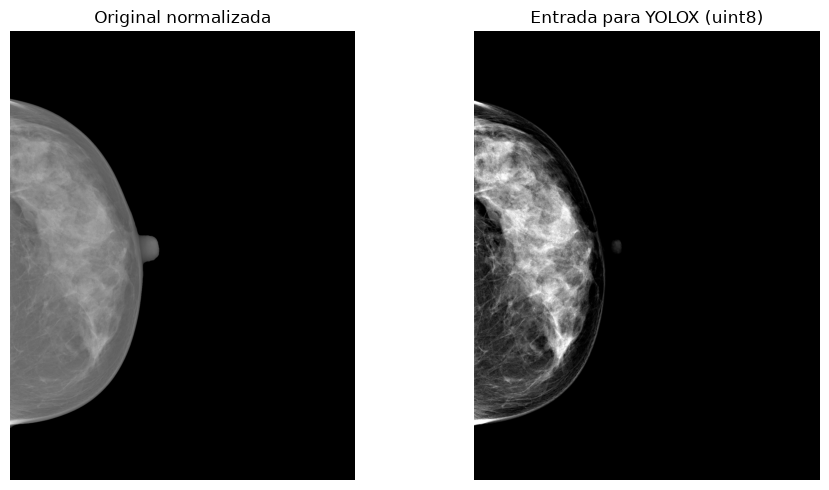

In [5]:
# Convertimos a uint8 para YOLOX
arr = windowed_image.astype('float32')
arr_min, arr_max = float(arr.min()), float(arr.max())
if arr_max > arr_min:
    arr = (arr - arr_min) / (arr_max - arr_min)
image_uint8 = (arr * 255.0).clip(0, 255).astype('uint8')

# YOLOXNotebookInterface acepta grayscale o RGB/BGR
image_for_yolo = image_uint8

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original normalizada')
axes[0].axis('off')

axes[1].imshow(image_uint8, cmap='gray')
axes[1].set_title('Entrada para YOLOX (uint8)')
axes[1].axis('off')

plt.tight_layout()

## YOLO 

In [6]:
predictor = YOLOXNotebookInterface(
    exp_file=str(EXP_FILE),
    ckpt_path=str(CKPT_FILE),
    device=DEVICE,
    conf=CONF,
    nms=NMS,
    tsize=TSIZE,
    fp16=False,
    yolox_root=str(YOLOX_ROOT),
)
print('Predictor inicializado correctamente')

Predictor inicializado correctamente


In [7]:
detections = predictor.predict(image_for_yolo, input_format='BGR')
print(f'Detecciones: {len(detections)}')

for i, det in enumerate(detections[:10]):
    print(f"[{i}] bbox={det['bbox_xyxy']} score={det['score']:.4f} class={det['class_name']}")

Detecciones: 1
[0] bbox=[5.13153076171875, 506.28857421875, 969.897216796875, 2929.011474609375] score=0.9882 class=person


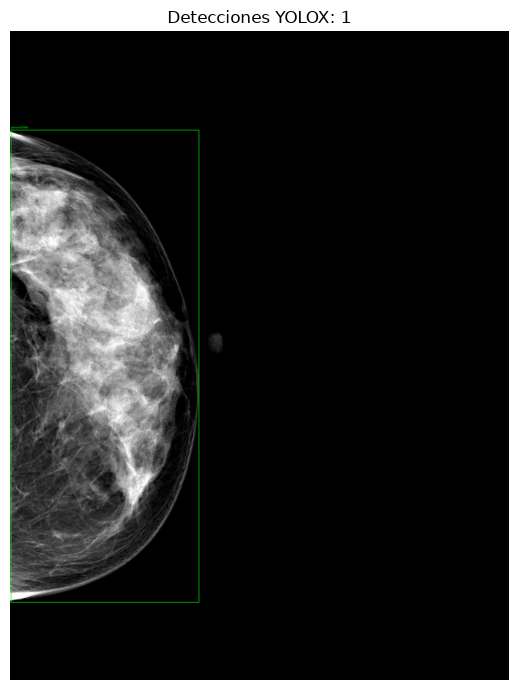

In [8]:
detections, vis_rgb = predictor.predict_with_image(image_for_yolo, input_format='BGR')

plt.figure(figsize=(7, 7))
plt.imshow(vis_rgb)
plt.title(f'Detecciones YOLOX: {len(detections)}')
plt.axis('off')
plt.tight_layout()

## Segmentacion MAseg (musculo pectoral)

Esta seccion reutiliza la misma imagen preprocesada para ejecutar segmentacion MAseg.
La salida esperada es una mascara con clases:
- 0: fondo
- 1: mama
- 2: musculo pectoral

In [10]:
from common_tasks.wrappers.segmentation import MAsegPectoralSegmentationInterface

MASEG_WEIGHTS = project_root / 'common_tasks/segmentation/BreastSegmentationUnet/maseg/weights/segmentation_weights.ckpt'
MASEG_ROOT = project_root / 'common_tasks/segmentation/BreastSegmentationUnet/maseg'

print('maseg root exists:', MASEG_ROOT.exists(), MASEG_ROOT)
print('maseg weights exists:', MASEG_WEIGHTS.exists(), MASEG_WEIGHTS)

maseg = MAsegPectoralSegmentationInterface(
    weights_path=str(MASEG_WEIGHTS),
    maseg_root=str(MASEG_ROOT),
)
print('MAseg inicializado correctamente')

maseg root exists: True /workspace/common_tasks/segmentation/BreastSegmentationUnet/maseg
maseg weights exists: True /workspace/common_tasks/segmentation/BreastSegmentationUnet/maseg/weights/segmentation_weights.ckpt


RuntimeError: Unable to import MAseg RunModel. Ensure MAseg dependencies are installed in the same environment as the notebook kernel.

In [11]:
segmentation_mask = maseg.segment(image_for_yolo, fill_holes_in_breast=True)
pectoral_mask = maseg.pectoral_mask(segmentation_mask)
stats = maseg.summary(segmentation_mask)

print('Resumen de pixeles por clase:')
print(stats)

breast_overlay, pectoral_overlay = maseg.overlay(image_for_yolo, segmentation_mask, alpha=0.35)

NameError: name 'maseg' is not defined

NameError: name 'segmentation_mask' is not defined

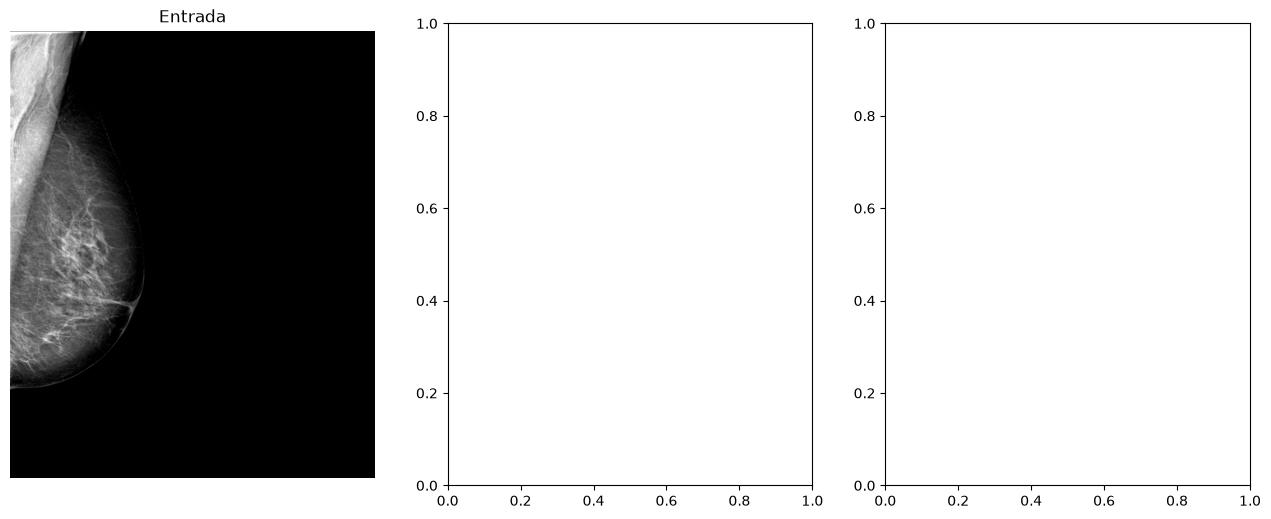

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(image_for_yolo, cmap='gray')
axes[0].set_title('Entrada')
axes[0].axis('off')

axes[1].imshow(segmentation_mask, cmap='viridis')
axes[1].set_title('MAseg: 0 fondo, 1 mama, 2 pectoral')
axes[1].axis('off')

axes[2].imshow(pectoral_overlay)
axes[2].set_title('Overlay musculo pectoral')
axes[2].axis('off')

plt.tight_layout()

## Prueba opcional via APIs (Docker Compose)

Si ejecutas `docker compose up -d`, puedes testear inferencia remota desde el notebook.

Importante segun donde corre el kernel:
- Kernel en contenedor preprocessing-notebook: usar http://yolox-api:8001/infer y http://maseg-api:8002/infer.
- Kernel local (host): usar http://localhost:8001/infer y http://localhost:8002/infer.

Las siguientes celdas autodetectan esto y permiten override con variables de entorno:
- YOLOX_API_URL
- MASEG_API_URL

In [11]:
import os
from pathlib import Path

import cv2
import numpy as np
import requests

in_docker = Path('/.dockerenv').exists()
default_yolox_url = 'http://yolox-api:8001/infer' if in_docker else 'http://localhost:8001/infer'
default_maseg_url = 'http://maseg-api:8002/infer' if in_docker else 'http://localhost:8002/infer'

YOLOX_API_URL = os.getenv('YOLOX_API_URL', default_yolox_url)
MASEG_API_URL = os.getenv('MASEG_API_URL', default_maseg_url)

if 'image_for_yolo' not in globals():
    # Fallback para probar conectividad API sin ejecutar todas las celdas previas.
    image_for_yolo = np.zeros((416, 416), dtype=np.uint8)

ok, encoded_png = cv2.imencode('.png', image_for_yolo)
if not ok:
    raise RuntimeError('No se pudo codificar image_for_yolo a PNG')

payload = encoded_png.tobytes()
print('Kernel en docker:', in_docker)
print('YOLOX_API_URL:', YOLOX_API_URL)
print('MASEG_API_URL:', MASEG_API_URL)

Kernel en docker: True
YOLOX_API_URL: http://yolox-api:8001/infer
MASEG_API_URL: http://maseg-api:8002/infer


In [12]:
# YOLOX API
try:
    resp_yolo = requests.post(
        YOLOX_API_URL,
        files={'file': ('image.png', payload, 'image/png')},
        data={'input_format': 'BGR'},
        timeout=60,
    )
except requests.RequestException as exc:
    print('YOLOX connection error:', exc)
else:
    print('YOLOX status:', resp_yolo.status_code)
    if resp_yolo.ok:
        yolo_json = resp_yolo.json()
        print('YOLOX detecciones:', yolo_json.get('num_detections'))
        print('Primera deteccion:', (yolo_json.get('detections') or [None])[0])
    else:
        print(resp_yolo.text)

YOLOX status: 200
YOLOX detecciones: 1
Primera deteccion: {'bbox_xyxy': [5.13153076171875, 506.28857421875, 969.897216796875, 2929.011474609375], 'score': 0.988239586353302, 'class_id': 0, 'class_name': 'person'}


In [13]:
# MAseg API
try:
    resp_maseg = requests.post(
        MASEG_API_URL,
        files={'file': ('image.png', payload, 'image/png')},
        data={'include_pectoral_mask': False, 'fill_holes_in_breast': True},
        timeout=60,
    )
except requests.RequestException as exc:
    print('MAseg connection error:', exc)
else:
    print('MAseg status:', resp_maseg.status_code)
    if resp_maseg.ok:
        maseg_json = resp_maseg.json()
        print('MAseg summary:', maseg_json.get('summary'))
    else:
        print(resp_maseg.text)

MAseg connection error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
